In [18]:
# pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [19]:
df = pd.DataFrame({
    "age" : [25, 28, 37, 41, 44, 29, 31, 35, 38, 40], 
    "iq"  : [30, 45, 46, 50, 28, 40, 55, 60, 65, 70],
    "communication" : [5, 6, 7, 9, 5, 8, 9, 10, 11, 12],
    "leadership" : [4, 5, 6, 7, 4, 8, 6, 7, 8, 9],
    "discipline" : [3, 4, 5, 6, 2, 4, 5, 6, 7, 8],
    "salary" : [30000, 40000, 50000, 60000, 30000, 40000, 50000, 60000, 70000, 80000]
})
df

,age,iq,communication,leadership,discipline,salary
0,25,30,5,4,3,30000
1,28,45,6,5,4,40000
2,37,46,7,6,5,50000
3,41,50,9,7,6,60000
4,44,28,5,4,2,30000
5,29,40,8,8,4,40000
6,31,55,9,6,5,50000
7,35,60,10,7,6,60000
8,38,65,11,8,7,70000
9,40,70,12,9,8,80000


In [20]:
X = df[["age", "iq", "communication", "leadership", "discipline"]] #independent variable
y = df["salary"]  #dependent variable

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [22]:
x_train

,age,iq,communication,leadership,discipline
0,25,30,5,4,3
7,35,60,10,7,6
2,37,46,7,6,5
9,40,70,12,9,8
4,44,28,5,4,2
3,41,50,9,7,6
6,31,55,9,6,5


In [23]:
y_train

0    30000
7    60000
2    50000
9    80000
4    30000
3    60000
6    50000
Name: salary, dtype: int64

In [24]:
x_test

,age,iq,communication,leadership,discipline
8,38,65,11,8,7
1,28,45,6,5,4
5,29,40,8,8,4


In [25]:
y_test

8    70000
1    40000
5    40000
Name: salary, dtype: int64

In [26]:
model = LinearRegression()
model.fit(x_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred = model.predict(x_test)

In [28]:
y_pred

array([70000., 40000., 70000.])

In [29]:
df2 = pd.DataFrame({
    "Actual Salary" : y_test,
    "Predicted Salary" : y_pred
})
df2

,Actual Salary,Predicted Salary
8,70000,70000.0
1,40000,40000.0
5,40000,70000.0


In [34]:
mean_absolute_error(y_test, y_pred), root_mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)

(9999.999999999944, 17320.508075688664, -0.4999999999999811)

In [31]:
model.coef_ , model.intercept_  # y = mx + c   # m = coefficient, c = intercept


# y = model.coef_ * x + model.intercept_   

(array([3.08360585e-12, 9.09494702e-13, 5.40012479e-12, 1.00000000e+04,
        3.89945853e-11]),
 np.float64(-10000.000000000044))

<Axes: xlabel='age', ylabel='salary'>

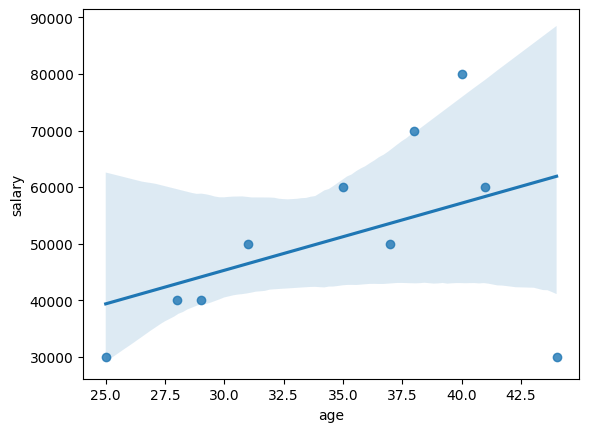

In [32]:
sns.regplot(x = "age", y = "salary", data = df)

In [33]:
df.to_excel("sample.xlsx", index = False )